In [21]:
import scanpy as sc
import umap
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import trustworthiness, TSNE
from metrics import pairwise_distance_correlation, knn_accuracy, knn_recall
from sklearn.metrics import silhouette_score

from IsUMap import IsUMap

import time

**Загрузка данных**

In [22]:
adata = sc.datasets.paul15()

In [23]:
print(adata)
print(adata.X.shape)

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'
(2730, 3451)


In [24]:
adata.obs

,paul15_clusters
W31105,7MEP
W31106,15Mo
W31107,3Ery
W31108,15Mo
W31109,3Ery
...,...
W39164,2Ery
W39165,13Baso
W39166,7MEP
W39167,15Mo


In [25]:
adata.var

""
0610007L01Rik
0610009O20Rik
0610010K14Rik
0910001L09Rik
1100001G20Rik
...
mKIAA1027
mKIAA1575
mKIAA1994
rp9


In [26]:
sc.tl.pca(adata, n_comps=50)

adata.obsm['X_pca']

array([[-6.97771988e+01, -4.84666252e+01,  5.25239611e+00, ...,
         1.15876484e+00,  2.45635226e-01, -9.37248707e-01],
       [-1.86681881e+01,  9.64854507e+01,  3.09644008e+00, ...,
        -3.84954238e+00, -3.95407033e+00,  4.93950081e+00],
       [ 1.10527954e+02, -1.99393330e+01,  3.29010701e+00, ...,
        -1.82515705e+00,  8.55317831e-01,  6.16070092e-01],
       ...,
       [-6.64900436e+01, -4.58280067e+01,  5.60931730e+00, ...,
        -3.20206434e-01, -1.88223213e-01, -1.26881689e-01],
       [ 3.55648232e+00,  8.70996933e+01, -5.46125746e+00, ...,
        -7.03908110e+00,  2.90438390e+00,  4.93248224e+00],
       [ 1.85102051e+02, -4.13937521e+00, -6.04300308e+00, ...,
        -6.06986618e+00,  2.82531285e+00,  3.87041593e+00]],
      shape=(2730, 50), dtype=float32)

In [27]:
X = adata.obsm['X_pca'][:, :50].astype(np.float32)
labels = adata.obs['paul15_clusters'].astype(str).to_numpy()

In [28]:
n_neighbors_list = [10, 30, 50, 100]
n_runs = 5
seeds = [42 + i for i in range(n_runs)]


**Применение UMAP**

In [29]:
X_umap_list = []
umap_times = []
for el in n_neighbors_list:
    X_umap_runs = []
    umap_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        reducer = umap.UMAP(
            n_neighbors=el,
            metric='euclidean',
            random_state=seed,
        )
        X_umap = reducer.fit_transform(X)
        end = time.perf_counter()

        umap_time_runs.append(end - start)
        X_umap_runs.append(X_umap)

    umap_times.append(umap_time_runs)
    X_umap_list.append(X_umap_runs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no 

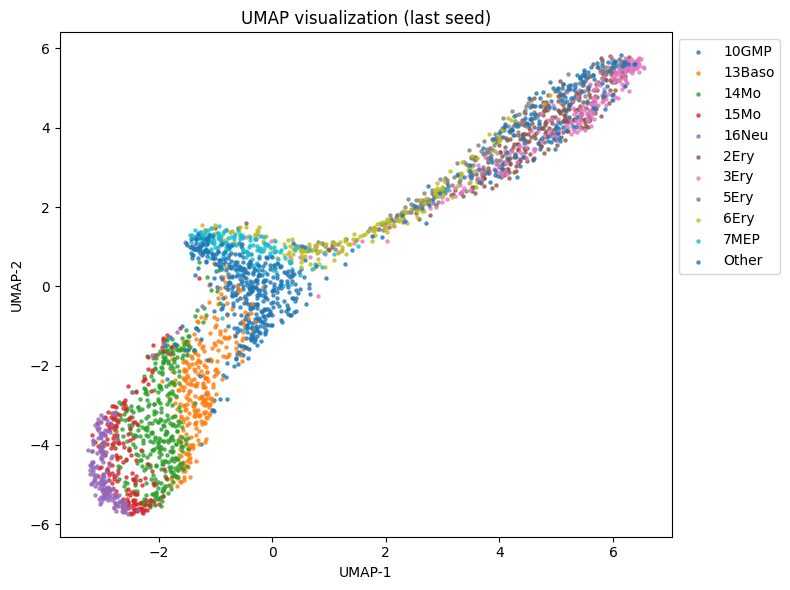

In [42]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_umap_list[-1][-1][m,0], X_umap_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('UMAP visualization (last seed)')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Применение IsUMap**

In [31]:
X_isumap_list = []
isumap_times = []
for el in n_neighbors_list:
    X_isumap_runs = []
    isumap_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        isumap = IsUMap(
            n_neighbors=el,
            n_components=2,
            metric='euclidean',
            mode='um',
            use_rho=True,
            random_state=seed,
        )
        X_isumap = isumap.fit_transform(X)
        end = time.perf_counter()

        isumap_time_runs.append(end - start)
        X_isumap_runs.append(X_isumap)

    isumap_times.append(isumap_time_runs)
    X_isumap_list.append(X_isumap_runs)


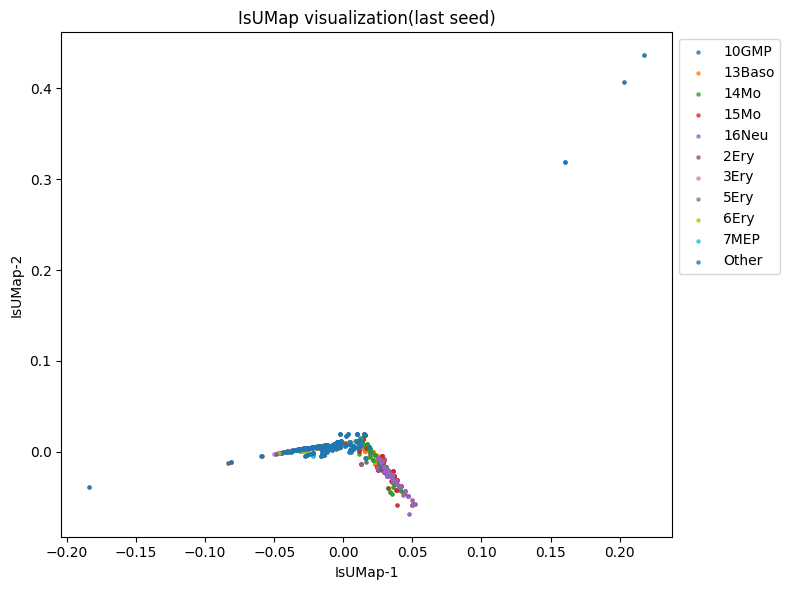

In [43]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_isumap_list[-1][-1][m,0], X_isumap_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('IsUMap visualization(last seed)')
plt.xlabel('IsUMap-1'); plt.ylabel('IsUMap-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Сравнение**

In [33]:
# Time
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    print(f'UMAP time: {np.mean(umap_times[i]):.6f} +- {np.std(umap_times[i]):.6f}')
    print(f'IsUMap time: {np.mean(isumap_times[i]):.6f} +- {np.std(isumap_times[i]):.6f}')
    print()


n_neighbors = 10
UMAP time: 4.872131 +- 0.036159
IsUMap time: 4.740663 +- 0.064254

n_neighbors = 30
UMAP time: 11.821103 +- 0.027047
IsUMap time: 10.777788 +- 0.053169

n_neighbors = 50
UMAP time: 18.780880 +- 0.029453
IsUMap time: 16.087100 +- 0.177992

n_neighbors = 100
UMAP time: 36.397014 +- 0.322416
IsUMap time: 27.618500 +- 0.747092



In [34]:
# Trustworthiness
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    tw_umap_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_umap_list[i]]
    tw_isumap_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_isumap_list[i]]

    print(f'UMAP trustworthiness: {np.mean(tw_umap_runs):.6f} +- {np.std(tw_umap_runs):.6f}')
    print(f'IsUMap trustworthiness: {np.mean(tw_isumap_runs):.6f} +- {np.std(tw_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP trustworthiness: 0.976530 +- 0.000201
IsUMap trustworthiness: 0.931801 +- 0.000000

n_neighbors = 30
UMAP trustworthiness: 0.972591 +- 0.000237
IsUMap trustworthiness: 0.931424 +- 0.000000

n_neighbors = 50
UMAP trustworthiness: 0.969052 +- 0.000806
IsUMap trustworthiness: 0.935236 +- 0.000000

n_neighbors = 100
UMAP trustworthiness: 0.963844 +- 0.000660
IsUMap trustworthiness: 0.935677 +- 0.000000



In [35]:
# pairwise_distance_correlation
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    sp_corr_umap_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_umap_list[i]]
    sp_corr_isumap_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_isumap_list[i]]

    print(f'UMAP spearman corr: {np.mean(sp_corr_umap_runs):.6f} +- {np.std(sp_corr_umap_runs):.6f}')
    print(f'IsUMap spearman corr: {np.mean(sp_corr_isumap_runs):.6f} +- {np.std(sp_corr_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP spearman corr: 0.732068 +- 0.005241
IsUMap spearman corr: 0.647410 +- 0.000000

n_neighbors = 30
UMAP spearman corr: 0.718612 +- 0.004152
IsUMap spearman corr: 0.650959 +- 0.000000

n_neighbors = 50
UMAP spearman corr: 0.729951 +- 0.013772
IsUMap spearman corr: 0.649561 +- 0.000000

n_neighbors = 100
UMAP spearman corr: 0.748554 +- 0.021255
IsUMap spearman corr: 0.647853 +- 0.000000



In [36]:
# knn-accuracy
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    acc_umap_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_umap_list[i]]
    acc_isumap_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_isumap_list[i]]

    print(f'UMAP kNN accuracy: {np.mean(acc_umap_runs):.6f} +- {np.std(acc_umap_runs):.6f}')
    print(f'IsUMap kNN accuracy: {np.mean(acc_isumap_runs):.6f} +- {np.std(acc_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP kNN accuracy: 0.611941 +- 0.002805
IsUMap kNN accuracy: 0.518315 +- 0.000000

n_neighbors = 30
UMAP kNN accuracy: 0.600586 +- 0.003386
IsUMap kNN accuracy: 0.514286 +- 0.000000

n_neighbors = 50
UMAP kNN accuracy: 0.583370 +- 0.003725
IsUMap kNN accuracy: 0.513553 +- 0.000000

n_neighbors = 100
UMAP kNN accuracy: 0.557070 +- 0.002321
IsUMap kNN accuracy: 0.518315 +- 0.000000



In [37]:
# knn-recall
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    knn_recall_umap_runs = [knn_recall(X, emb) for emb in X_umap_list[i]]
    knn_recall_isumap_runs = [knn_recall(X, emb) for emb in X_isumap_list[i]]

    print(f'UMAP kNN recall: {np.mean(knn_recall_umap_runs):.6f} +- {np.std(knn_recall_umap_runs):.6f}')
    print(f'IsUMap kNN recall: {np.mean(knn_recall_isumap_runs):.6f} +- {np.std(knn_recall_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP kNN recall: 0.282388 +- 0.001792
IsUMap kNN recall: 0.223040 +- 0.000000

n_neighbors = 30
UMAP kNN recall: 0.222234 +- 0.001194
IsUMap kNN recall: 0.218352 +- 0.000000

n_neighbors = 50
UMAP kNN recall: 0.198557 +- 0.001865
IsUMap kNN recall: 0.220440 +- 0.000000

n_neighbors = 100
UMAP kNN recall: 0.166198 +- 0.003304
IsUMap kNN recall: 0.220256 +- 0.000000



In [38]:
# silhouette
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    silhouette_umap_runs = [silhouette_score(emb, labels) for emb in X_umap_list[i]]
    silhouette_isumap_runs = [silhouette_score(emb, labels) for emb in X_isumap_list[i]]

    print(f'UMAP silhouette: {np.mean(silhouette_umap_runs):.6f} +- {np.std(silhouette_umap_runs):.6f}')
    print(f'IsUMap silhouette: {np.mean(silhouette_isumap_runs):.6f} +- {np.std(silhouette_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP silhouette: -0.117048 +- 0.001808
IsUMap silhouette: -0.166067 +- 0.000000

n_neighbors = 30
UMAP silhouette: -0.166955 +- 0.011155
IsUMap silhouette: -0.172171 +- 0.000000

n_neighbors = 50
UMAP silhouette: -0.152947 +- 0.019216
IsUMap silhouette: -0.171360 +- 0.000000

n_neighbors = 100
UMAP silhouette: -0.142695 +- 0.012152
IsUMap silhouette: -0.170312 +- 0.000000



**Применение t-SNE и метрики**

In [39]:
X_tsne_list = []
tsne_times = []
for el in n_neighbors_list:
    X_tsne_runs = []
    tsne_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        tsne = TSNE(
            n_components=2,
            perplexity=el,
            metric='euclidean',
            init='pca',
            learning_rate='auto',
            random_state=seed,
        )
        X_tsne = tsne.fit_transform(X)
        end = time.perf_counter()

        tsne_time_runs.append(end - start)
        X_tsne_runs.append(X_tsne)

    tsne_times.append(tsne_time_runs)
    X_tsne_list.append(X_tsne_runs)


In [40]:
for i in range(len(n_neighbors_list)):
    print(f'perplexity = {n_neighbors_list[i]}')
    print(f't-SNE time: {np.mean(tsne_times[i]):.6f} +- {np.std(tsne_times[i]):.6f}')

    tw_tsne_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_tsne_list[i]]
    print(f't-SNE trustworthiness: {np.mean(tw_tsne_runs):.6f} +- {np.std(tw_tsne_runs):.6f}')

    sp_corr_tsne_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_tsne_list[i]]
    print(f't-SNE spearman corr: {np.mean(sp_corr_tsne_runs):.6f} +- {np.std(sp_corr_tsne_runs):.6f}')

    acc_tsne_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_tsne_list[i]]
    print(f't-SNE kNN accuracy: {np.mean(acc_tsne_runs):.6f} +- {np.std(acc_tsne_runs):.6f}')

    knn_recall_tsne_runs = [knn_recall(X, emb) for emb in X_tsne_list[i]]
    print(f't-SNE kNN recall: {np.mean(knn_recall_tsne_runs):.6f} +- {np.std(knn_recall_tsne_runs):.6f}')

    silhouette_tsne_runs = [silhouette_score(emb, labels) for emb in X_tsne_list[i]]
    print(f't-SNE silhouette: {np.mean(silhouette_tsne_runs):.6f} +- {np.std(silhouette_tsne_runs):.6f}')
    print()

perplexity = 10
t-SNE time: 3.021835 +- 0.108476
t-SNE trustworthiness: 0.985094 +- 0.000117
t-SNE spearman corr: 0.723566 +- 0.010201
t-SNE kNN accuracy: 0.648498 +- 0.003638
t-SNE kNN recall: 0.397516 +- 0.000727
t-SNE silhouette: -0.080287 +- 0.005598

perplexity = 30
t-SNE time: 3.646842 +- 0.055739
t-SNE trustworthiness: 0.986584 +- 0.000151
t-SNE spearman corr: 0.830079 +- 0.001888
t-SNE kNN accuracy: 0.656337 +- 0.002794
t-SNE kNN recall: 0.400696 +- 0.000386
t-SNE silhouette: -0.078618 +- 0.001120

perplexity = 50
t-SNE time: 4.500692 +- 0.237808
t-SNE trustworthiness: 0.986856 +- 0.000109
t-SNE spearman corr: 0.853924 +- 0.001669
t-SNE kNN accuracy: 0.659853 +- 0.003942
t-SNE kNN recall: 0.391377 +- 0.001513
t-SNE silhouette: -0.084407 +- 0.005902

perplexity = 100
t-SNE time: 4.823304 +- 0.187023
t-SNE trustworthiness: 0.985003 +- 0.000042
t-SNE spearman corr: 0.844633 +- 0.000118
t-SNE kNN accuracy: 0.651648 +- 0.000463
t-SNE kNN recall: 0.344513 +- 0.000149
t-SNE silhouette

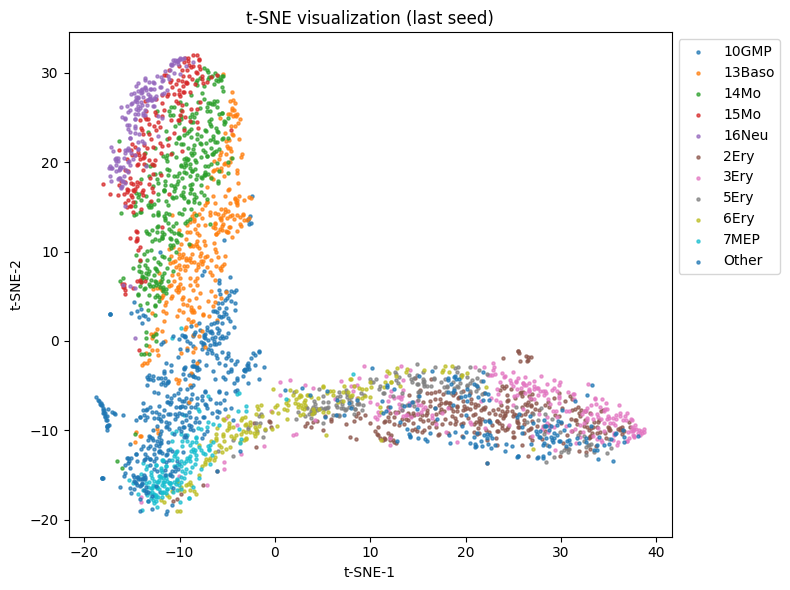

In [44]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_tsne_list[-1][-1][m,0], X_tsne_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('t-SNE visualization (last seed)')
plt.xlabel('t-SNE-1'); plt.ylabel('t-SNE-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()
